# Load Data

In [1]:
import pickle

In [2]:
with open('orbitals.pkl', 'rb') as f:
    orbitals = pickle.load(f)

with open('maneuvers.pkl', 'rb') as f:
    maneuvers = pickle.load(f)

# Check day time uniform and interpolate

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime

In [4]:
man = maneuvers['srl']

In [5]:
df = orbitals['SARAL.csv'].copy()
df = df[['Brouwer mean motion']].copy()
df.rename(columns={"Brouwer mean motion": "mean_motion"}, inplace=True)

In [6]:
df.index = pd.to_datetime(df.index)

# keep only year-month-day
df.index = df.index.normalize()

In [7]:
df.index.duplicated().any()

False

In [8]:
df.index = pd.to_datetime(df.index)
diffs = df.index.to_series().diff()
is_uniform = diffs[1:] == diffs[1]

print(f"is uniform interval in days?：{is_uniform.all()}")
print(f"interval count：{diffs.value_counts().head()}")

is uniform interval in days?：False
interval count：day_time
1 days    3120
2 days     160
3 days       4
4 days       4
7 days       1
Name: count, dtype: int64


In [9]:
most_common_diff = diffs.value_counts().idxmax()

# check which dates have problems
irregular_times = diffs[diffs != most_common_diff]

print("Following dtaes records not in uniform：")
print(irregular_times) # without 16-03-04 as this date is initial strart day

Following dtaes records not in uniform：
day_time
2013-03-10      NaT
2013-03-13   2 days
2013-03-20   2 days
2013-03-25   2 days
2013-03-30   2 days
              ...  
2019-11-16   2 days
2020-03-13   3 days
2020-05-26   2 days
2020-11-11   4 days
2022-06-19   4 days
Name: day_time, Length: 170, dtype: timedelta64[ns]


In [10]:
# df = df.asfreq('D')  # set day as freq
# df = df.interpolate() 

In [11]:
df.index = pd.to_datetime(df.index)
diffs = df.index.to_series().diff()
is_uniform = diffs[1:] == diffs[1]

print(f"is uniform interval in days?：{is_uniform.all()}")
print(f"interval count：{diffs.value_counts().head()}")

is uniform interval in days?：False
interval count：day_time
1 days    3120
2 days     160
3 days       4
4 days       4
7 days       1
Name: count, dtype: int64


# Time-series Plot

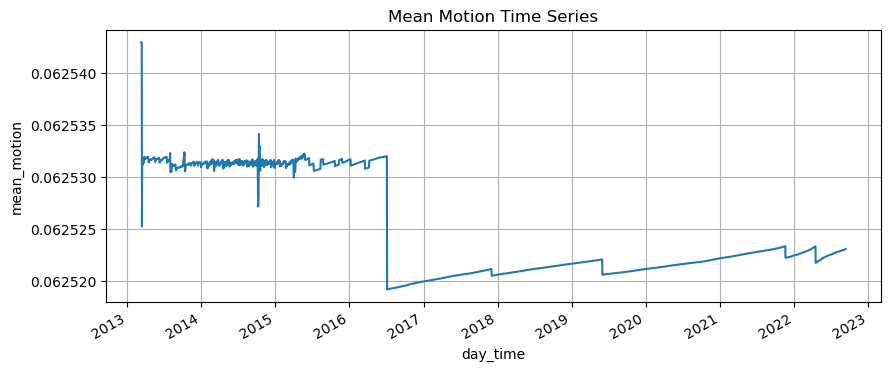

In [12]:
plt.figure(figsize=(10, 4))
df['mean_motion'].plot(title='Mean Motion Time Series')
plt.ylabel("mean_motion")
plt.grid(True)
plt.show()

# Split data and pre-process

In [13]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor

In [14]:
# # Log and RobustScaler
df_scaled = df.copy()
df_scaled = (df_scaled - df_scaled.mean()) * 1e7

# df_scaled = np.log1p(df_scaled)
# median = df_scaled.median()
# iqr = df_scaled.quantile(0.75) - df_scaled.quantile(0.25)

# df_scaled = (df_scaled - median) / iqr
# df_scaled = (df_scaled - df_scaled.mean()) / df_scaled.std()

In [15]:
df_scaled.head()
# df_scaled.dropna(inplace=True)

,mean_motion
day_time,
2013-03-10,183.347553
2013-03-11,183.547089
2013-03-13,182.319672
2013-03-14,6.448535
2013-03-15,66.248920


In [16]:
# # create lag features
# NUM_LAG_FEATURES = 7  # consider tuned in future
# df_x = pd.DataFrame({"bmm_lag_1": df_scaled["mean_motion"]})
# for lag in range(2, NUM_LAG_FEATURES + 1):
#     df_x[f"bmm_lag_{lag}"] = df_scaled["mean_motion"].shift(lag)

In [17]:
# # drop na becuase n rows are used created lags
# df_x = df_x.iloc[NUM_LAG_FEATURES:].copy()
# df_y = df_scaled["mean_motion"].iloc[NUM_LAG_FEATURES:].copy()

In [18]:
# # split train and test use test as val to tuning paramters
# ratio = 0.8
# n_total = len(df_x)
# n_train = int(n_total * ratio)

# df_x_train = df_x.iloc[:n_train]
# df_x_test  = df_x.iloc[n_train:]

# df_y_train = df_y.iloc[:n_train]
# df_y_test  = df_y.iloc[n_train:]

In [19]:
# print("train shape:", df_x_train.shape, df_y_train.shape)
# print("test  shape:", df_x_test.shape,  df_y_test.shape)

In [20]:
def make_lagged_features(series, num_lags=3, train_ratio=0.8):

    series = series.copy()
    
    # 1. get lag features
    df_x = pd.DataFrame({f"lag_1": series})
    for lag in range(2, num_lags + 1):
        df_x[f"lag_{lag}"] = series.shift(lag)
    
    # 2. from lags with na rows
    df_x = df_x.iloc[num_lags:].copy()
    df_y = series.iloc[num_lags:].copy()
    
    # 3. split in train and test
    n_total = len(df_x)
    n_train = int(n_total * train_ratio)
    
    df_x_train = df_x.iloc[:n_train]
    df_x_test  = df_x.iloc[n_train:]
    
    df_y_train = df_y.iloc[:n_train]
    df_y_test  = df_y.iloc[n_train:]
    
    return df_x_train, df_x_test, df_y_train, df_y_test

# XGBoost Model Build and Tuning (inlcude lag features)

In [21]:
from sklearn.model_selection import ParameterGrid

In [22]:
param_dict = {
    'n_estimators': [100],
    'max_depth': [3],
    'learning_rate': [0.04, 0.05, 0.06],
    'reg_lambda':[0.1, 0.5, 1, 5],
    # 'subsample':[0.8, 0.9],
    # 'colsample_bytree':[0.8, 0.9],
    # 'min_child_weight': [3, 5, 7],
    'num_lag_features': [12]
}

grid = list(ParameterGrid(param_dict))

In [23]:
results = []
models  = []

for params in grid:
    # take out lags
    num_lags = params.pop('num_lag_features')
    
    df_x_train, df_x_test, df_y_train, df_y_test = make_lagged_features(
        df_scaled['mean_motion'],
        num_lags=num_lags,
        train_ratio=0.8
    )
    
    model = XGBRegressor(
        **params,
        eval_metric='mae',
        early_stopping_rounds = 10
    )

    model.fit(
        df_x_train, df_y_train,
        eval_set=[
            (df_x_train, df_y_train),
            (df_x_test, df_y_test)
        ],
        verbose=False
    )

    preds = model.predict(df_x_test)
    mae = mean_absolute_error(df_y_test, preds)

    results.append({
        **params,  # XGB Paras
        'num_lag_features': num_lags,
        'best_iteration': model.best_iteration,
        'test_mae': mae
    })
    models.append(model)

results_df = pd.DataFrame(results)

In [24]:
results_df.sort_values(by='test_mae', ascending=True).head(10)

,learning_rate,max_depth,n_estimators,reg_lambda,num_lag_features,best_iteration,test_mae
6,0.05,3,100,1.0,12,99,2.696112
10,0.06,3,100,1.0,12,99,2.696127
2,0.04,3,100,1.0,12,99,2.706221
1,0.04,3,100,0.5,12,57,2.775038
5,0.05,3,100,0.5,12,45,2.777523
9,0.06,3,100,0.5,12,37,2.783580
8,0.06,3,100,0.1,12,34,2.813578
0,0.04,3,100,0.1,12,52,2.813683
4,0.05,3,100,0.1,12,36,2.865209
11,0.06,3,100,5.0,12,62,6.529950


In [25]:
# get targeted
mask = (results_df["test_mae"] < 10) & (results_df["test_mae"] > 0)
best_idx = results_df[mask]["test_mae"].idxmin()
best_model = models[best_idx]

print(f"\nBest model is at index {best_idx} with params:", 
      results_df.loc[best_idx])


Best model is at index 6 with params: learning_rate         0.050000
max_depth             3.000000
n_estimators        100.000000
reg_lambda            1.000000
num_lag_features     12.000000
best_iteration       99.000000
test_mae              2.696112
Name: 6, dtype: float64


evals_result keys: dict_keys(['validation_0', 'validation_1'])


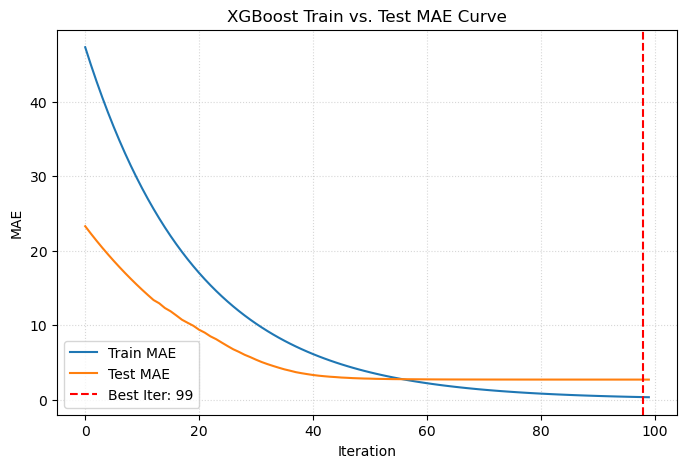

In [26]:
# plt train and test loss changes
evals = best_model.evals_result()

print("evals_result keys:", evals.keys()) 

train_mae = evals['validation_0']['mae']  # train mae
test_mae = evals['validation_1']['mae']   # test mae

iters = range(len(train_mae))

plt.figure(figsize=(8, 5))
plt.plot(iters, train_mae, label='Train MAE')
plt.plot(iters, test_mae, label='Test MAE')

best_iter = best_model.best_iteration - 1  
plt.axvline(
    x=best_iter,
    color='red',
    linestyle='--',
    label=f'Best Iter: {best_model.best_iteration}'
)

plt.xlabel('Iteration')
plt.ylabel('MAE')
plt.title('XGBoost Train vs. Test MAE Curve')
plt.legend()
plt.grid(linestyle=':', alpha=0.5)
plt.show()

# Fit with tuned XGB models

In [27]:
# get para
row = results_df.loc[best_idx]
best_params = {param: row[param] for param in param_dict.keys() if param in row}

for param in best_params:
    if param in ['n_estimators', 'max_depth', 'min_child_weight']:
        best_params[param] = int(best_params[param])
    elif param in ['learning_rate', 'subsample', 'colsample_bytree', 'reg_lambda']:
        best_params[param] = float(best_params[param])

print("selected paras：", best_params)

selected paras： {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'reg_lambda': 1.0, 'num_lag_features': 12.0}


In [28]:
# create all data in selected features
NUM_LAG_FEATURES = 12  
df_x = pd.DataFrame({"bmm_lag_1": df_scaled["mean_motion"]})
for lag in range(2, NUM_LAG_FEATURES + 1):
    df_x[f"bmm_lag_{lag}"] = df_scaled["mean_motion"].shift(lag)

In [29]:
df_x = df_x.iloc[NUM_LAG_FEATURES:].copy()
df_y = df_scaled["mean_motion"].iloc[NUM_LAG_FEATURES:].copy()

In [30]:
final_xgb = XGBRegressor(
    n_estimators = 100, 
    max_depth = 3,
    learning_rate = 0.06,
    reg_lambda = 1.0,
    # subsample = 0.7,
    # colsample_bytree = 0.7,
    # min_child_weight = 3,
    objective     ='reg:squarederror',
    eval_metric   ='mae')

In [31]:
# fit with entire data
final_xgb.fit(df_x.values, df_y.values)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='mae', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.06, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [32]:
pred_all = final_xgb.predict(df_x)

In [33]:
pred_all

array([ 70.69267,  73.48879,  71.88753, ..., -15.42031, -15.42031,
       -15.42031], dtype=float32)

In [34]:
xgb_pred = pd.DataFrame({
    'actual': df_y.values,
    'pred':   pred_all
}, index=df_y.index)

In [35]:
orig_mean      = df["mean_motion"].mean()
scale_factor   = 1e7

In [36]:
xgb_pred["actual_orig"] = xgb_pred["actual"] / scale_factor + orig_mean
xgb_pred["pred_orig"] = xgb_pred["pred" ] / scale_factor + orig_mean

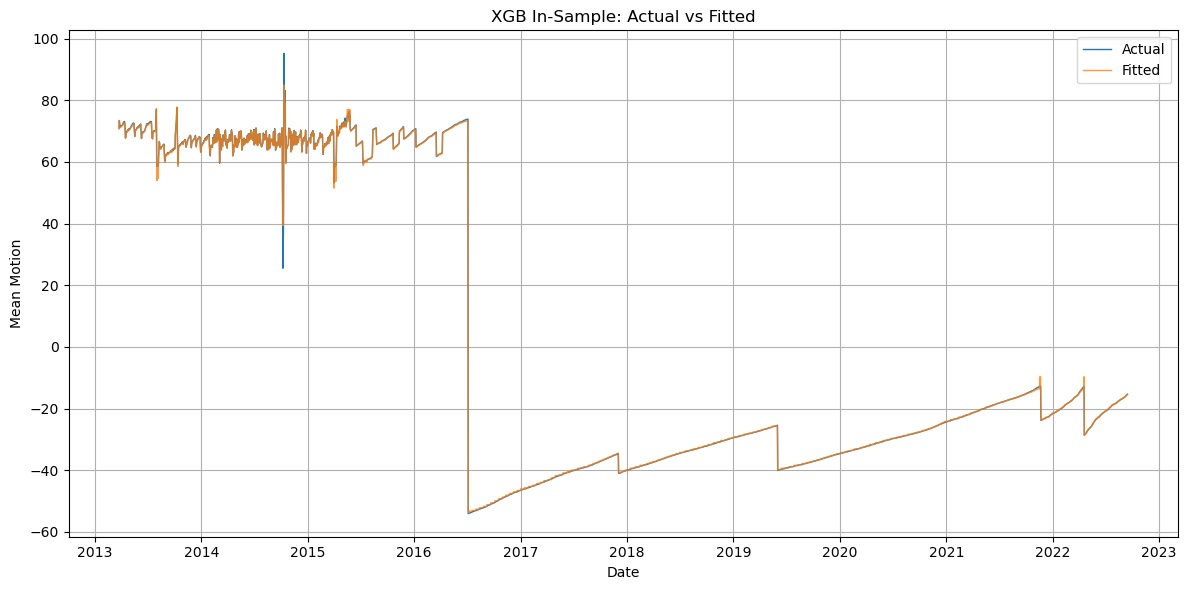

In [37]:
plt.figure(figsize=(12, 6))
plt.plot(xgb_pred.index, xgb_pred["actual"], label="Actual", linewidth=1)
plt.plot(xgb_pred.index, xgb_pred["pred"], label="Fitted", linewidth=1, alpha=0.8)

plt.title("XGB In‑Sample: Actual vs Fitted")
plt.xlabel("Date")
plt.ylabel("Mean Motion")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Get XGB Residual from prediction vs true value

In [38]:
# xgb_pred['residual_orig'] = xgb_pred['actual_orig'] - xgb_pred['pred_orig']
xgb_pred['residual'] = xgb_pred['actual'] - xgb_pred['pred']

In [39]:
xgb_pred.to_csv("result/saral_xgb_residuals.csv", index=True)

# Check residuals - distribution and QQ

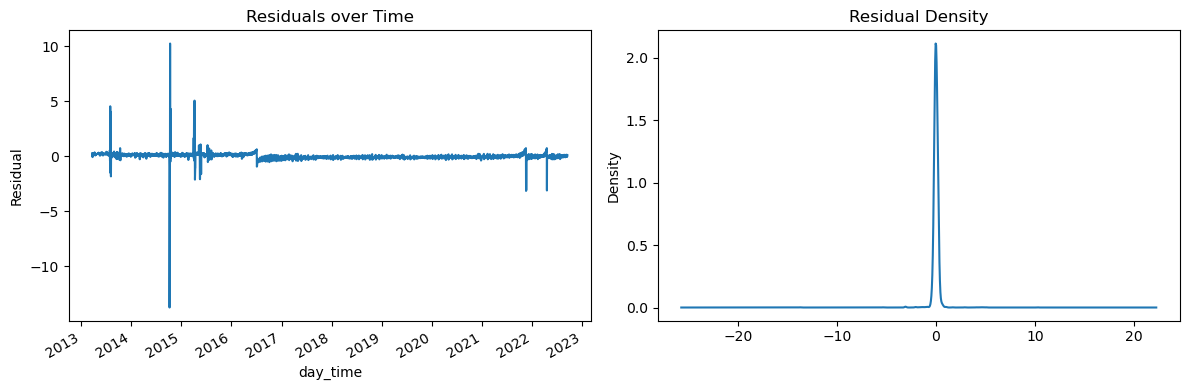

In [40]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

xgb_pred['residual'].plot(ax=ax[0], title="Residuals over Time")
ax[0].set_ylabel("Residual")

xgb_pred['residual'].plot(kind='kde', ax=ax[1], title="Residual Density")

plt.tight_layout()
plt.show()

In [41]:
import scipy.stats as stats

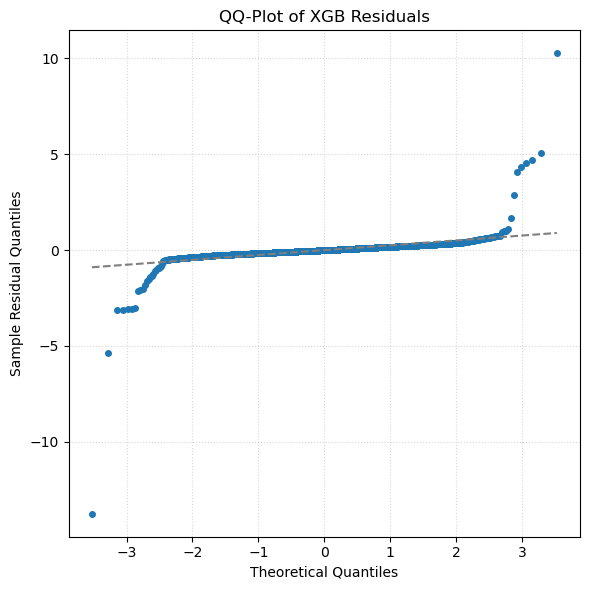

In [42]:
xgb_res = xgb_pred['residual']

# get qq plts for res
fig, ax = plt.subplots(figsize=(6,6))
stats.probplot(xgb_res, dist="norm", plot=ax)

dots, line = ax.get_lines()
dots.set_marker('o')
dots.set_markersize(4)
dots.set_color('tab:blue')

line.set_linestyle('--')
line.set_color('tab:gray')

ax.grid(True, linestyle=':', alpha=0.5)
ax.set_title("QQ-Plot of XGB Residuals")
ax.set_xlabel("Theoretical Quantiles")
ax.set_ylabel("Sample Residual Quantiles")

plt.tight_layout()
plt.show()

# Extract anomlies

In [43]:
import scipy.stats as sts

In [44]:
# get mean and sd for res
mu    = xgb_res.mean()
sigma = xgb_res.std()

In [45]:
# p_low, p_high = sts.norm.cdf([-2.6, +2.4])
# print("percentile range", p_low, p_high)

In [46]:
# low, high = xgb_res.quantile([p_low, p_high])
# print("anomlies thresholds selected：", low, high)

# get anomalies
# anomalies = xgb_res[(xgb_res < low) | (xgb_res > high)]
anomalies = xgb_res[np.abs(xgb_res - mu) > 2 * sigma]
print("num of anomalies：", len(anomalies))

num of anomalies： 32


# Visulize result

In [47]:
manoeuvre_dates = pd.to_datetime(man['median_day_time']).dt.date
manoeuvre_dates = pd.to_datetime(manoeuvre_dates)
manoeuvre_dates = manoeuvre_dates[manoeuvre_dates.isin(df.index)]

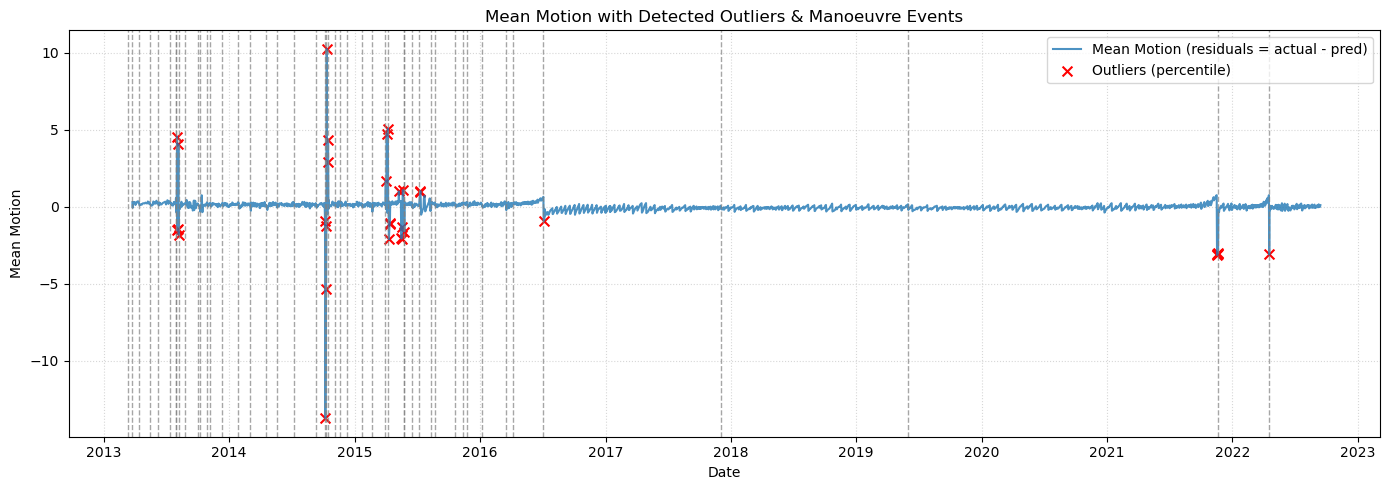

In [48]:
plt.figure(figsize=(14, 5))

# # 1) plt actual
# plt.plot(arima_pred.index, 
#          arima_pred['actual'], 
#          label='Mean Motion (actual)', 
#          color='C0', 
#          alpha=0.8)

# 1) plt -residuals
plt.plot(xgb_pred.index, 
         xgb_pred['residual'], 
         label='Mean Motion (residuals = actual - pred)', 
         color='C0', 
         alpha=0.8)

# 2) plt man
for dt in manoeuvre_dates:
    plt.axvline(x=dt,
                color='gray',
                linestyle='--',
                linewidth=1,
                alpha=0.7)
    
# 3) plt anomalies
plt.scatter(
    anomalies.index,
    xgb_pred.loc[anomalies.index, 'residual'],
    color='red',
    marker='x',
    s=50,
    label='Outliers (percentile)'
)

plt.title("Mean Motion with Detected Outliers & Manoeuvre Events")
plt.xlabel("Date")
plt.ylabel("Mean Motion")
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

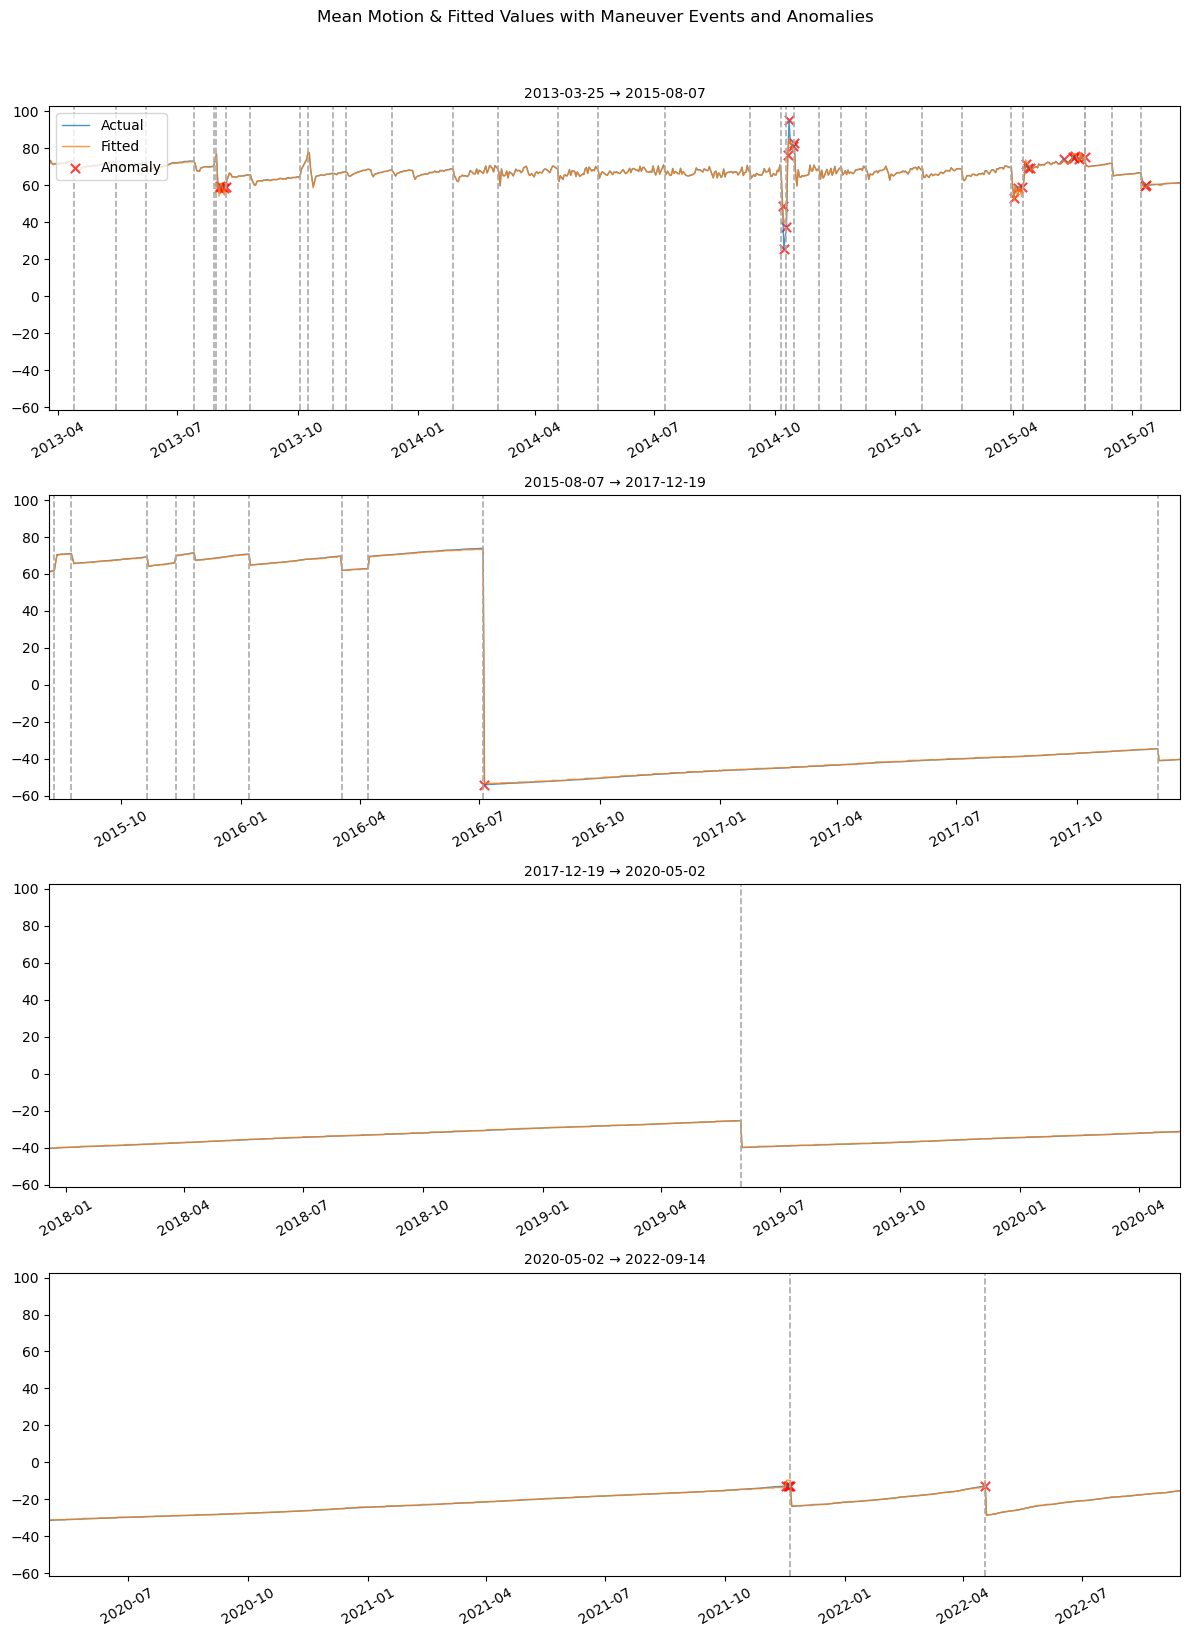

In [49]:
# get multi-cols plts
start, end = xgb_pred.index.min(), xgb_pred.index.max()
knots = pd.date_range(start, end, periods=5)
intervals = list(zip(knots[:-1], knots[1:]))

fig, axes = plt.subplots(4, 1, figsize=(12, 16), sharey=True)

for ax, (seg_start, seg_end) in zip(axes, intervals):
    segment = xgb_pred.loc[seg_start:seg_end]
    
    # actual
    ax.plot(
        segment.index, segment['actual'],
        label='Actual', color='#1f77b4', alpha=0.8, linewidth=1.0
    )
    # plt fitted
    ax.plot(
        segment.index, segment['pred'],
        label='Fitted', color='#ff7f0e', alpha=0.8, linewidth=1.0
    )
    
    # # plt -residuals
    # plt.plot(arima_pred.index, 
	# 		arima_pred['residual'], 
	# 		label='Mean Motion (residuals = actual - pred)', 
	# 		color='C0', 
	# 		alpha=0.8)
    
    # 3) plt anomalies
    idx1 = anomalies.loc[seg_start:seg_end].index
    ax.scatter(
        idx1,
        segment.loc[idx1, 'actual'],
        color='red', 
        marker='x',
        alpha = 0.75,
        s=45,
        label='Anomaly'
    )
    
    # 4) plt man
    for dt in manoeuvre_dates:
        if seg_start <= dt <= seg_end:
            ax.axvline(
                x=dt, color='#aaaaaa',
                linestyle='--', linewidth=1.2, alpha=1.0
            )
    
    # tight layout
    ax.set_xlim(seg_start, seg_end)
    # ax.grid(True, linestyle=':', alpha=0.5)
    ax.set_title(f"{seg_start.date()} → {seg_end.date()}", fontsize=10)
    ax.tick_params(axis='x', rotation=30)
    
    if ax is axes[0]:
        ax.legend(loc='upper left')

fig.suptitle(
    "Mean Motion & Fitted Values with Maneuver Events and Anomalies",
    y=1.02, fontsize=12
)
plt.tight_layout()
plt.show()

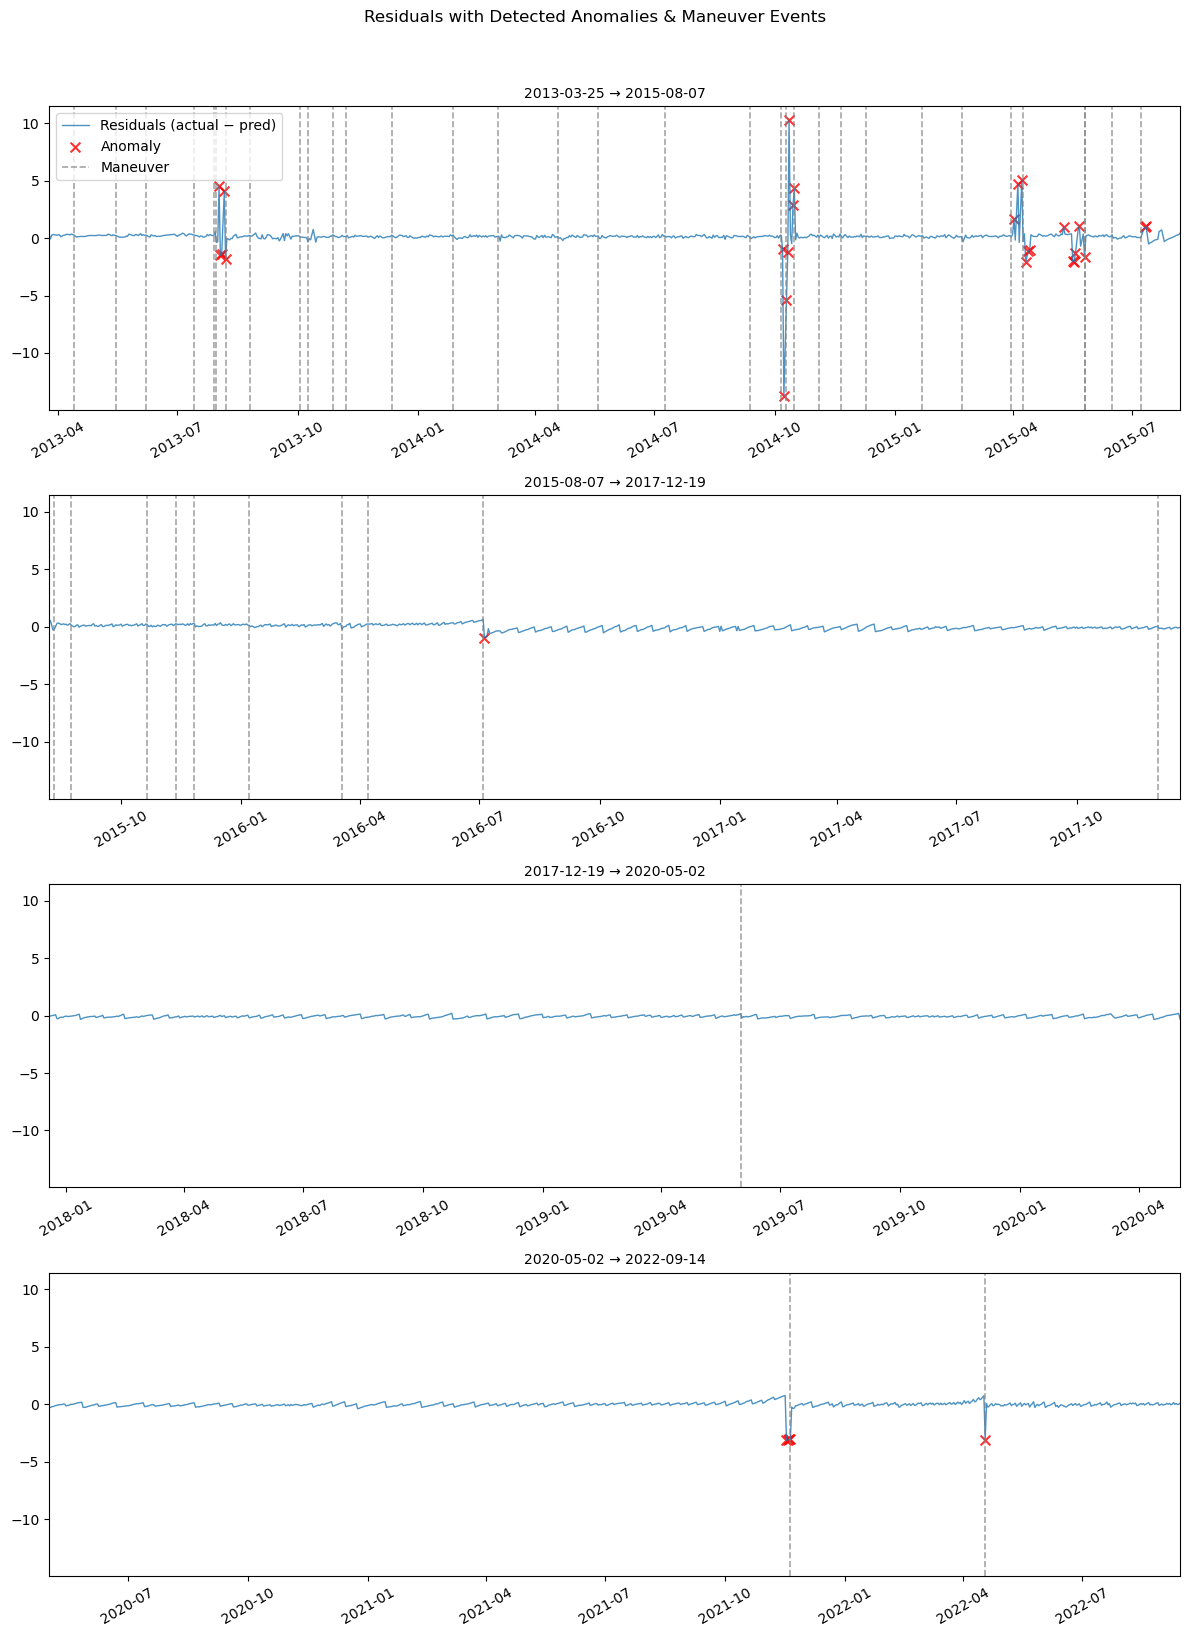

In [50]:
# residuals

fig, axes = plt.subplots(4, 1, figsize=(12, 16), sharey=True)

for ax, (seg_start, seg_end) in zip(axes, intervals):
    segment = xgb_pred.loc[seg_start:seg_end]
    
    ax.plot(
        segment.index, segment['residual'],
        label='Residuals (actual − pred)',
        color='C0', alpha=0.8, linewidth=1.0
    )

    idx1 = anomalies.loc[seg_start:seg_end].index
    ax.scatter(
        idx1, segment.loc[idx1, 'residual'],
        color='red', marker='x', s=50, alpha=0.8,
        label='Anomaly'
    )
    
    first = True
    for dt in manoeuvre_dates:
        if seg_start <= dt <= seg_end:
            ax.axvline(
                x=dt, color='gray', linestyle='--',
                linewidth=1.2, alpha=0.7,
                label='Maneuver' if first else None
            )
            first = False
    
    ax.set_xlim(seg_start, seg_end)
    ax.set_title(f"{seg_start.date()} → {seg_end.date()}", fontsize=10)
    ax.tick_params(axis='x', rotation=30)
    if ax is axes[0]:
        ax.legend(loc='upper left')

fig.suptitle(
    "Residuals with Detected Anomalies & Maneuver Events",
    y=1.02, fontsize=12
)
plt.tight_layout()
plt.show()

# Record num of man and anomlies

In [51]:
# records num of anomlies and man
man_df   = man.copy()             # man
anom_idx = anomalies.index        # outliers index

man_days  = pd.to_datetime(man_df['median_day_time']).dt.normalize()
anom_days = anom_idx.normalize()

anom_set = set(anom_days)

# check deteced in +- n days range
n = 3 

matched_manoeuvres = []
unmatched_manoeuvres = []

for d in man_days:
    window = set(d + pd.to_timedelta(offset, unit='D') for offset in range(-n, n+1))
    
    if window & anom_set:
        matched_manoeuvres.append(d)
    else:
        unmatched_manoeuvres.append(d)

summary = pd.DataFrame({
    "category": [
        "total_manoeuvres",
        "total_anomalies",
        f"manoeuvres_matched_within_±{n}d",
        f"manoeuvres_unmatched_within_±{n}d"
    ],
    "count": [
        len(man_days),
        len(anom_days),
        len(matched_manoeuvres),
        len(unmatched_manoeuvres)
    ]
})

summary

,category,count
0,total_manoeuvres,62
1,total_anomalies,32
2,manoeuvres_matched_within_±3d,13
3,manoeuvres_unmatched_within_±3d,49


In [52]:
summary.to_csv("result/saral_xgb_result.csv", index=False)